# Optimización computacional

La Sección 4 de la guía pide reducir el coste sin perder desempeño y **sustentar cada mejora en
su complejidad asintótica**, contrastada con tiempos medidos. Este capítulo:

1. Presenta la complejidad teórica de cada modelo, en su versión estándar y en la optimizada.
2. Perfila una evaluación típica del estudio para identificar el cuello de botella real.
3. Mide, modelo por modelo, la versión estándar frente a la optimizada **variando n de forma
   controlada** y estima el exponente empírico de la curva de escalamiento (pendiente log-log).
4. Mide el efecto del paralelismo (`n_jobs`, backends de joblib) y de la GPU en XGBoost.
5. Resume todo en la tabla estándar frente a optimizado que exige la guía.

Todas las mediciones usan la partición externa `e0` del capítulo 02: ~197 mil filas de
entrenamiento y ~49 mil de validación, con ~600 columnas. Las curvas de escalamiento toman
fracciones anidadas del entrenamiento (1/8, 1/4, 1/2, 1) para estimar el exponente; el punto final
es siempre el conjunto completo. Cada experimento se guarda en `resultados/estudios/computacional/`
y no se repite al re-ejecutar; un experimento que falla no detiene los demás.

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
import gc, time
from sklearn.metrics import roc_auc_score
from src import experimento as ex, modelos as mod, balanceo as bal, complejidad as cx, espacios

DIR_CX = config.DIR_ESTUDIOS / "computacional"
DIR_CX.mkdir(parents=True, exist_ok=True)
REP = 1 if config.MODO_PRUEBA else 3            # repeticiones por medición

cache = ex.CacheParticiones()
externa, internas = cache.pliegue(0)
X_tr = np.asarray(externa.X_tr); y_tr = np.asarray(externa.y_tr).astype(int)
X_va = np.asarray(externa.X_va); y_va = np.asarray(externa.y_va).astype(int)
n_total, p = X_tr.shape
FRACCIONES = [1 / 8, 1 / 4, 1 / 2, 1]
rng = np.random.default_rng(config.SEMILLA)
orden = rng.permutation(n_total)                # subconjuntos anidados
def sub(frac):
    idx = np.sort(orden[: int(frac * n_total)])
    return X_tr[idx], y_tr[idx]
print(f"Entrenamiento: {n_total:,} x {p} | validación: {len(y_va):,}")

Entrenamiento: 196,806 x 609 | validación: 49,202


## 1. Complejidad teórica

n = observaciones, p = columnas, d = dimensión del PCA, T = árboles, K = hojas por árbol,
i = iteraciones, m = componentes de Nystroem, B = bins del histograma.

In [3]:
display(cx.COMPLEJIDAD)

,Modelo,Version,Entrenamiento,Inferencia
0,KNN,"estandar (fuerza bruta, p dims)",O(1) (memoriza),O(n p) por consulta
1,KNN,KD-Tree / Ball-Tree,O(n log n),O(log n) en dims bajas; degenera a O(n p) en d...
2,KNN,PCA(d) + FAISS plano,O(n p d) (PCA),"O(n d) por consulta, vectorizado/multihilo"
3,KNN,PCA(d) + fuerza bruta en GPU (PyTorch),O(n p d) (PCA),"O(n d) por consulta, bloques de 1024 consultas..."
4,KNN,PCA(d) + FAISS IVF,O(n p d + n d nlist) (k-medias),O((n/nlist) d nprobe) por consulta (aproximado)
5,Naive Bayes,fit,O(n p),O(p) por consulta
6,Naive Bayes,partial_fit (lotes),O(n p) con memoria O(b p),O(p) por consulta
7,Logistica / Ridge / Lasso,lbfgs / Cholesky,O(n p^2 + p^3) (Ridge) | O(i n p) (lbfgs),O(p)
8,Logistica / Ridge / Lasso,SAGA,O(n p) por epoca,O(p)
9,Lasso,coordenadas + Gram,O(n p^2) una vez + O(i p^2),O(p)


## 2. Perfilamiento: ¿dónde se va el tiempo?

Antes de optimizar se perfila una evaluación completa del estudio: balanceo con SMOTE +
ajuste de un Random Forest + predicción, sobre la partición interna `e0/i0`. `cProfile` da el tiempo
por función y `memory_profiler` el pico de memoria residente (incluye la que reservan las bibliotecas
en C, que `tracemalloc` no ve).

In [4]:
def perfil_evaluacion():
    pi = internas[0]
    params = espacios.espacio("clasificacion", "random_forest").centro()
    def una_eval():
        Xb, yb = bal.aplicar("smote", np.asarray(pi.X_tr), np.asarray(pi.y_tr))
        est, info = mod.entrenar("clasificacion", "random_forest", params, "smote", Xb, yb,
                                 X_balanceado=(Xb, yb))
        s = mod.puntuar(est, pi.X_va, "clasificacion")
        return roc_auc_score(np.asarray(pi.y_va), s)
    perfil, auc = cx.perfilar(una_eval, top=15)
    mem, _ = cx.medir_memoria_rss(una_eval)
    perfil["auc"] = auc
    perfil["pico_memoria_mb"] = mem
    return perfil

perfil = cx.experimento_en_disco(DIR_CX / "perfil_evaluacion.csv", perfil_evaluacion)
if perfil is not None:
    display(perfil.style.format(precision=3))

,funcion,llamadas,t_propio_s,t_acumulado_s,auc,pico_memoria_mb
0,inner_f (core.py:710),19,0.000,32.811,0.706,936.336
1,entrenar (modelos.py:390),1,0.000,32.081,0.706,936.336
2,fit (sklearn.py:1849),1,0.000,32.081,0.706,936.336
3,_run_once (base_events.py:1874),8,0.000,23.975,0.706,936.336
4,select (selectors.py:319),8,0.000,21.975,0.706,936.336
5,_select (selectors.py:313),8,0.000,21.974,0.706,936.336
6,(~:0),8,21.974,21.974,0.706,936.336
7,fit (sklearn.py:1598),1,0.000,8.095,0.706,936.336
8,train (training.py:32),1,0.000,8.094,0.706,936.336
9,update (core.py:2225),1,8.047,8.047,0.706,936.336


**Lectura.** De los 32.8 s de la evaluación perfilada (SMOTE más un bosque de XGBoost en la GPU
sobre `e0/i0`), el SMOTE (`fit_resample`) consume 2.8 s, cerca del 9 %, y la construcción de los
árboles (`update` de XGBoost) 8.0 s. Los ~22 s restantes aparecen como espera del hilo de Python
(`select`) dentro del ajuste: es tiempo en que el intérprete está bloqueado mientras trabajan el
código nativo y la GPU, que `cProfile` no puede desglosar por función. Aunque una aplicación de SMOTE
es una fracción modesta de una evaluación, se repetiría en todas: con 20 evaluaciones y 4
optimizadores, calcular el balanceo una sola vez por partición y compartirlo evita 79 de cada 80
aplicaciones, unos 3.7 minutos por partición interna en este modelo y bastante más con ADASYN, cuya
aplicación la estimación previa midió en ~9 s. El pico de memoria residente (936 MB) confirma que
una evaluación cabe con holgura en los 16 GB del equipo; el límite efectivo fue la memoria de la
GPU (anexo A).

## 3. KNN: búsqueda exhaustiva, árboles de indexación y FAISS

Se comparan seis estrategias para los k = 50 vecinos de 5,000 consultas de validación:

* fuerza bruta de scikit-learn sobre las **~600 columnas originales** (el KNN "de libro");
* fuerza bruta, KD-Tree y Ball-Tree sobre un PCA de 40 componentes;
* FAISS exacto (`IndexFlatL2`) y FAISS aproximado (`IndexIVFFlat`, 1,024 celdas, 16 visitadas) sobre el
  mismo PCA;
* búsqueda exacta por fuerza bruta en la GPU con PyTorch (la que usa el estudio), también sobre el PCA.

Para el índice aproximado se mide además el *recall@k* frente a la búsqueda exacta: la fracción de
los verdaderos k vecinos que recupera. Es el compromiso exactitud-velocidad de la búsqueda aproximada.

In [5]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
K = 50
N_CONSULTAS = min(5000, len(y_va))
Xq_full, yq = X_va[:N_CONSULTAS], y_va[:N_CONSULTAS]

def experimento_knn():
    pca = PCA(n_components=min(40, p - 1), svd_solver="randomized", random_state=config.SEMILLA).fit(X_tr)
    filas = []
    for frac in FRACCIONES:
        Xs, ys = sub(frac)
        Zs = np.ascontiguousarray(pca.transform(Xs), dtype=np.float32)
        Zq = np.ascontiguousarray(pca.transform(Xq_full), dtype=np.float32)
        exactos = None
        estrategias = {
            "sklearn_bruta_p_original": ("sk", "brute", Xs, Xq_full),
            "sklearn_bruta_pca": ("sk", "brute", Zs, Zq),
            "kd_tree_pca": ("sk", "kd_tree", Zs, Zq),
            "ball_tree_pca": ("sk", "ball_tree", Zs, Zq),
            "faiss_plano_pca": ("faiss", "plano", Zs, Zq),
            "faiss_ivf_pca": ("faiss", "ivf", Zs, Zq),
        }
        if config.KNN_MOTOR == "torch":
            estrategias["torch_gpu_pca"] = ("torch", "plano", Zs, Zq)
        for nombre, (motor, alg, A, Q) in estrategias.items():
            if motor == "sk":
                t0 = time.perf_counter()
                nn = NearestNeighbors(n_neighbors=K, algorithm=alg, n_jobs=config.NUCLEOS).fit(A)
                t_fit = time.perf_counter() - t0
                t0 = time.perf_counter()
                _, I = nn.kneighbors(Q)
                t_q = time.perf_counter() - t0
            elif motor == "torch":
                import torch
                dev = "cuda" if torch.cuda.is_available() else "cpu"
                sincronizar = torch.cuda.synchronize if dev == "cuda" else (lambda: None)
                t0 = time.perf_counter()
                Ag = torch.from_numpy(A).to(dev); a2 = (Ag * Ag).sum(1)
                sincronizar(); t_fit = time.perf_counter() - t0
                t0 = time.perf_counter()
                Il = []
                for i in range(0, len(Q), 1024):
                    Qg = torch.from_numpy(Q[i:i + 1024]).to(dev)
                    d2 = (Qg * Qg).sum(1, keepdim=True) - 2 * Qg @ Ag.T + a2[None]
                    Il.append(torch.topk(d2, K, dim=1, largest=False).indices.cpu().numpy())
                sincronizar(); t_q = time.perf_counter() - t0
                I = np.vstack(Il); del Ag, a2
                if dev == "cuda":
                    torch.cuda.empty_cache()
            else:
                import faiss
                faiss.omp_set_num_threads(config.NUCLEOS)
                d = A.shape[1]
                t0 = time.perf_counter()
                if alg == "ivf":
                    nlist = int(max(1, min(1024, len(A) // 39)))
                    idx = faiss.IndexIVFFlat(faiss.IndexFlatL2(d), d, nlist)
                    idx.train(A); idx.nprobe = min(16, nlist)
                else:
                    idx = faiss.IndexFlatL2(d)
                idx.add(A)
                t_fit = time.perf_counter() - t0
                t0 = time.perf_counter()
                _, I = idx.search(Q, K)
                t_q = time.perf_counter() - t0
            I = np.where(I < 0, 0, I)
            if nombre == "sklearn_bruta_pca":
                exactos = I
            recall = (np.mean([len(set(a) & set(b)) / K for a, b in zip(I, exactos)])
                      if exactos is not None else np.nan)
            filas.append({"estrategia": nombre, "n": len(ys), "t_construccion_s": t_fit,
                          "t_consultas_s": t_q, "ms_por_consulta": 1000 * t_q / len(Q),
                          "auc": roc_auc_score(yq, ys[I].mean(1)), "recall_at_k": recall})
            print(f"  {nombre:26s} n={len(ys):>7,}  consulta {1000 * t_q / len(Q):7.3f} ms", flush=True)
    return pd.DataFrame(filas)

knn = cx.experimento_en_disco(DIR_CX / "knn.csv", experimento_knn)
if knn is not None:
    display(knn[knn["n"] == knn["n"].max()].style.format(precision=4))

,estrategia,n,t_construccion_s,t_consultas_s,ms_por_consulta,auc,recall_at_k
21,sklearn_bruta_p_original,196806,0.0954,7.6334,1.5267,0.6069,nan
22,sklearn_bruta_pca,196806,0.0034,1.1001,0.2200,0.6547,1.0000
23,kd_tree_pca,196806,1.8239,15.5481,3.1096,0.6547,1.0000
24,ball_tree_pca,196806,1.2708,23.7500,4.7500,0.6547,1.0000
25,faiss_plano_pca,196806,0.0119,0.5846,0.1169,0.6547,1.0000
26,faiss_ivf_pca,196806,1.0697,0.0578,0.0116,0.6484,0.9157
27,torch_gpu_pca,196806,1.1984,0.4319,0.0864,0.6547,1.0000


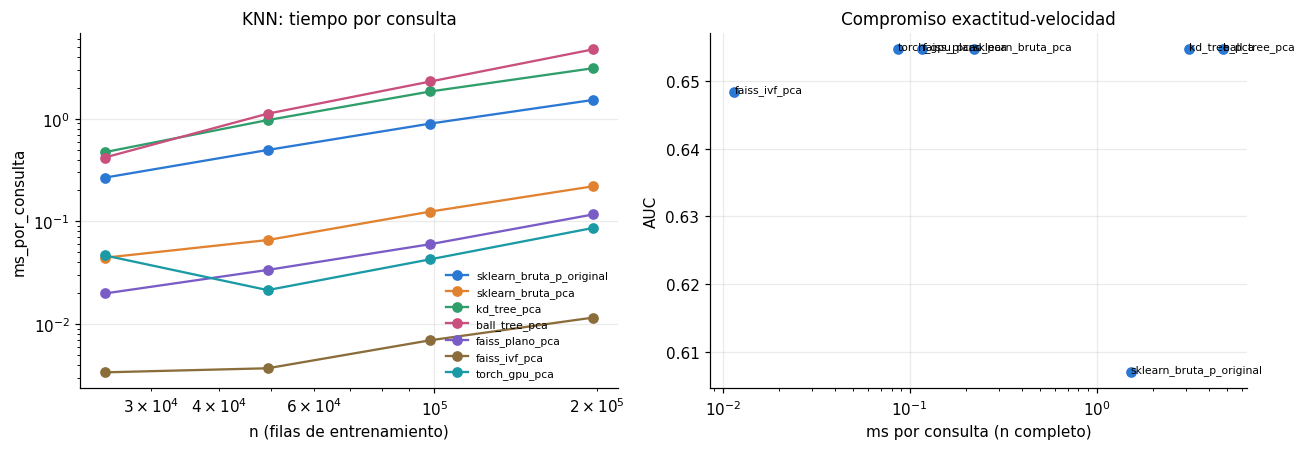

,estrategia,exponente,intercepto,r2
0,sklearn_bruta_p_original,0.840,-9.797,0.999
1,sklearn_bruta_pca,0.786,-11.127,0.992
2,kd_tree_pca,0.908,-9.883,0.995
3,ball_tree_pca,1.155,-12.468,0.994
4,faiss_plano_pca,0.851,-12.556,0.997
5,faiss_ivf_pca,0.623,-12.122,0.935
6,torch_gpu_pca,0.367,-7.219,0.330


In [6]:
def graficar_escalamiento(df, col_estrategia, col_tiempo, titulo, nombre_fig, ax=None):
    ax = ax or plt.subplots(figsize=(6.5, 4))[1]
    filas = []
    for e, g in df.groupby(col_estrategia, sort=False):
        g = g.sort_values("n")
        ax.loglog(g["n"], g[col_tiempo], marker="o", label=e)
        if len(g) >= 3 and (g[col_tiempo] > 0).all():
            filas.append({"estrategia": e, **cx.exponente_empirico(g["n"], g[col_tiempo])})
    ax.set_xlabel("n (filas de entrenamiento)"); ax.set_ylabel(col_tiempo)
    ax.set_title(titulo); ax.legend(fontsize=7)
    graficos.guardar(ax.figure, nombre_fig)
    return pd.DataFrame(filas)

if knn is not None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    exp_knn = graficar_escalamiento(knn, "estrategia", "ms_por_consulta",
                                    "KNN: tiempo por consulta", "05_knn_escalamiento", ax[0])
    g = knn[knn["n"] == knn["n"].max()]
    ax[1].scatter(g["ms_por_consulta"], g["auc"])
    for _, r in g.iterrows():
        ax[1].annotate(r["estrategia"], (r["ms_por_consulta"], r["auc"]), fontsize=7)
    ax[1].set_xscale("log"); ax[1].set_xlabel("ms por consulta (n completo)"); ax[1].set_ylabel("AUC")
    ax[1].set_title("Compromiso exactitud-velocidad")
    fig.tight_layout(); plt.show()
    display(exp_knn.style.format(precision=3))

**Lectura.** Las mediciones confirman la teoría con dos matices. La fuerza bruta escala casi
linealmente con n (exponentes 0.84 sobre las 609 columnas originales y 0.79 sobre el PCA; algo por
debajo de 1 porque una parte del coste es fija). KD-Tree y Ball-Tree en 40 dimensiones no ganan nada:
son 14 y 22 veces más lentos por consulta que la fuerza bruta sobre el mismo PCA (3.1 y 4.8 ms frente
a 0.22 ms), con exponentes 0.91 y 1.16, es decir, degeneran en una búsqueda casi exhaustiva con
sobrecoste, como anticipaba la tabla teórica. FAISS plano devuelve exactamente los mismos vecinos
(recall@k = 1) y es 1.9 veces más rápido que la fuerza bruta de scikit-learn; la búsqueda en la GPU
con PyTorch es la más rápida de las exactas (0.086 ms por consulta), y su exponente bajo (0.37, con
R² de 0.33) indica que a este tamaño domina un coste fijo, el de mover los datos a la GPU. FAISS IVF
es sublineal (exponente 0.62) y 10 veces más rápido que FAISS plano, a cambio de recuperar el 91.6 %
de los verdaderos vecinos, lo que baja el AUC de 0.6547 a 0.6484.

El resultado más relevante para el estudio es otro: reducir a 40 componentes no solo acelera 7
veces la fuerza bruta (de 1.53 a 0.22 ms por consulta), también **mejora** el AUC de 0.607 a 0.655.
En ~600 dimensiones las distancias se concentran y los vecinos más cercanos dejan de ser informativos;
el PCA es aquí una decisión de modelado, no solo de cómputo.

## 4. Modelos lineales: solvers para Ridge, Lasso y logística

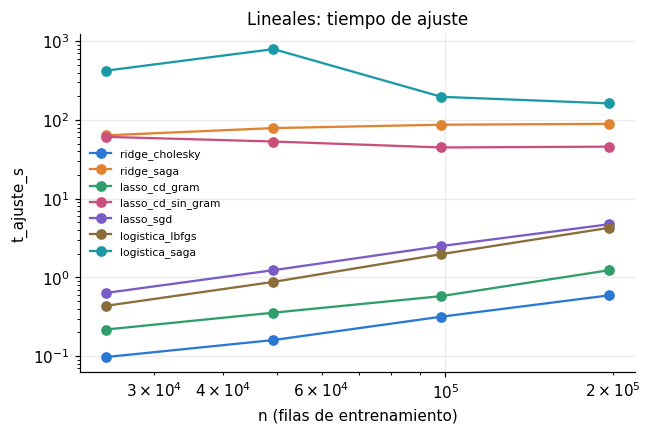

,estrategia,n,t_ajuste_s,sd_s,auc,iteraciones,alcanzo_max_iter
21,ridge_cholesky,196806,0.5913,0.0456,0.7515,0,False
22,ridge_saga,196806,89.0892,9.2407,0.7521,85,False
23,lasso_cd_gram,196806,1.2337,0.0863,0.7522,591,False
24,lasso_cd_sin_gram,196806,45.7329,0.0822,0.7522,590,False
25,lasso_sgd,196806,4.7319,0.0489,0.4937,6,False
26,logistica_lbfgs,196806,4.2655,0.0387,0.7542,56,False
27,logistica_saga,196806,162.1189,2.5405,0.7541,143,False


,estrategia,exponente,intercepto,r2
0,ridge_cholesky,0.880,-11.277,0.996
1,ridge_saga,0.160,2.584,0.873
2,lasso_cd_gram,0.822,-9.886,0.987
3,lasso_cd_sin_gram,-0.149,5.591,0.853
4,lasso_sgd,0.972,-10.286,1.000
5,logistica_lbfgs,1.106,-12.041,0.999
6,logistica_saga,-0.615,12.626,0.567


Ajustes que llegaron al tope de iteraciones sin converger:


estrategia,n,iteraciones,t_ajuste_s,auc
logistica_saga,24600,3000,421.3529,0.7330
logistica_saga,49201,3000,793.1618,0.7431


In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Ridge, Lasso, SGDRegressor, LogisticRegression

# Tope de iteraciones de cada solver. Que un solver lo alcance es un resultado del
# experimento (no convergio en ese presupuesto): se reporta en la tabla, columna
# `alcanzo_max_iter`, en lugar de dejar el aviso de scikit-learn en la salida.
MAX_ITER = {"ridge_saga": 1000, "lasso_cd_gram": 5000, "lasso_cd_sin_gram": 5000,
            "lasso_sgd": 50, "logistica_lbfgs": 3000, "logistica_saga": 3000}

def experimento_lineales():
    filas = []
    yv = y_va
    for frac in FRACCIONES:
        Xs, ys = sub(frac)
        yf = ys.astype(np.float32)
        candidatos = {
            "ridge_cholesky": lambda: Ridge(alpha=100.0, solver="cholesky"),
            "ridge_saga": lambda: Ridge(alpha=100.0, solver="saga", tol=1e-3, max_iter=1000,
                                        random_state=config.SEMILLA),
            "lasso_cd_gram": lambda: Lasso(alpha=1e-4, precompute=True, max_iter=5000),
            "lasso_cd_sin_gram": lambda: Lasso(alpha=1e-4, precompute=False, max_iter=5000),
            "lasso_sgd": lambda: SGDRegressor(penalty="l1", alpha=1e-4, max_iter=50, tol=1e-4,
                                              random_state=config.SEMILLA),
            "logistica_lbfgs": lambda: LogisticRegression(C=0.01, solver="lbfgs", max_iter=3000),
            "logistica_saga": lambda: LogisticRegression(C=0.01, solver="saga", max_iter=3000,
                                                         random_state=config.SEMILLA),
        }
        for nombre, f in candidatos.items():
            es_log = nombre.startswith("logistica")
            r = cx.medir(lambda: f().fit(Xs, ys if es_log else yf), repeticiones=REP)
            modelo = r["salida"]
            s = modelo.predict_proba(X_va)[:, 1] if es_log else modelo.predict(X_va)
            filas.append({"estrategia": nombre, "n": len(ys), "t_ajuste_s": r["media"],
                          "sd_s": r["sd"], "auc": roc_auc_score(yv, s),
                          "iteraciones": int(np.max(np.atleast_1d(getattr(modelo, "n_iter_", None) or 0)))})
        print(f"  n={len(ys):,} listo", flush=True)
    return pd.DataFrame(filas)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    lineales = cx.experimento_en_disco(DIR_CX / "lineales.csv", experimento_lineales)
if lineales is not None:
    lineales["alcanzo_max_iter"] = [it >= MAX_ITER[e] if e in MAX_ITER else False
                                    for e, it in zip(lineales["estrategia"], lineales["iteraciones"])]
    exp_lin = graficar_escalamiento(lineales, "estrategia", "t_ajuste_s",
                                    "Lineales: tiempo de ajuste", "05_lineales_escalamiento")
    plt.show()
    display(lineales[lineales["n"] == lineales["n"].max()].style.format(precision=4))
    display(exp_lin.style.format(precision=3))
    topes = lineales[lineales["alcanzo_max_iter"]]
    if len(topes):
        print("Ajustes que llegaron al tope de iteraciones sin converger:")
        display(topes[["estrategia", "n", "iteraciones", "t_ajuste_s", "auc"]]
                .style.format(precision=4).hide(axis="index"))

**Lectura.** En esta matriz densa (196,806 × 609) los solvers directos ganan con mucha diferencia y
SAGA no compensa en ningún caso. Ridge con Cholesky ajusta en 0.59 s frente a 89 s con SAGA (150
veces más lento) con el mismo AUC (0.7515 frente a 0.7521). En la logística, lbfgs tarda 4.3 s y SAGA
162 s, con AUC idéntico (0.7542 y 0.7541); con 24,600 y 49,201 filas SAGA ni siquiera convergió en
3,000 épocas (421 y 793 s). Es la explicación de la lentitud de la logística L1 en el estudio: en
scikit-learn la penalización L1 se ajustó con SAGA (anexo A).

Los exponentes de SAGA (0.16 en Ridge y −0.6 en la logística) no miden su coste por época, que es
lineal en n: miden que con más datos converge en menos épocas (Ridge: de 434 a 85; logística: de
3,000 a 143), y ese efecto compensa el mayor coste de cada época. Cholesky (exponente 0.88) y lbfgs
(1.11) escalan linealmente en n, como predice O(n p²) con p fijo. SAGA pasaría a ganar con p mucho
mayor —donde el p³ de Cholesky domina— o con datos dispersos, ninguno de los dos casos de este
problema.

En Lasso, precalcular la matriz de Gram lo hace 37 veces más rápido (1.23 s frente a 45.7 s) con el
mismo AUC: se paga O(n p²) una vez y luego cada iteración del descenso por coordenadas cuesta O(p²) en
lugar de O(n p). La alternativa SGD con penalización L1 queda descalificada: se detuvo en 6 épocas por
el criterio de tolerancia y su AUC (0.46-0.49) es peor que el azar, señal de que con la tasa de
aprendizaje por defecto no llegó a una solución útil.

## 5. Naive Bayes: aprendizaje incremental con `partial_fit`

`GaussianNB` solo necesita, por clase y columna, conteos, medias y varianzas, que se actualizan de
forma exacta por lotes. `partial_fit` permite entrenar sin tener el conjunto completo en memoria:
aquí se leen lotes de 20 mil filas desde la matriz mapeada en disco. Se comprueba que los parámetros
resultantes son los mismos y se compara el pico de memoria.

In [8]:
from sklearn.naive_bayes import GaussianNB
def experimento_nb():
    ruta = __import__("src").preprocesamiento.dir_particiones() / "e0" / "X_tr.npy"
    y_all = y_tr
    def completo():
        X = np.load(ruta)                        # carga toda la matriz
        return GaussianNB().fit(X, y_all)
    def incremental():
        X = np.load(ruta, mmap_mode="r")          # lee por lotes desde disco
        nb = GaussianNB()
        lote = 20_000
        for i in range(0, len(y_all), lote):
            nb.partial_fit(np.asarray(X[i:i + lote]), y_all[i:i + lote], classes=[0, 1])
        return nb
    filas = []
    for nombre, f in (("fit_completo", completo), ("partial_fit_lotes", incremental)):
        t = cx.medir(f, repeticiones=REP)
        mem, nb = cx.medir_memoria_rss(f)
        filas.append({"estrategia": nombre, "t_ajuste_s": t["media"], "pico_memoria_mb": mem,
                      "auc": roc_auc_score(y_va, nb.predict_proba(X_va)[:, 1]),
                      "theta_hash": float(np.round(nb.theta_.sum(), 6)),
                      "var_hash": float(np.round(nb.var_.sum(), 6))})
    return pd.DataFrame(filas)

nb_res = cx.experimento_en_disco(DIR_CX / "naive_bayes.csv", experimento_nb)
if nb_res is not None:
    display(nb_res.style.format(precision=6))

,estrategia,t_ajuste_s,pico_memoria_mb,auc,theta_hash,var_hash
0,fit_completo,0.872074,1329.785156,0.643951,8.704839,1262.833701
1,partial_fit_lotes,0.902015,561.011719,0.644119,8.705042,1262.975742


## 6. XGBoost: `exact` frente a `hist`, parada temprana y GPU

* `exact` ordena cada columna y evalúa todos los cortes posibles: O(T·K·p·n log n).
* `hist` discretiza cada columna en B = 256 bins una sola vez y construye histogramas de gradiente:
  O(T·K·p·n) por árbol con constante mucho menor, y paraleliza bien en GPU.
* La **parada temprana** detiene el boosting cuando el AUC de un conjunto de validación
  independiente (10 % del entrenamiento real) no mejora en 50 rondas.

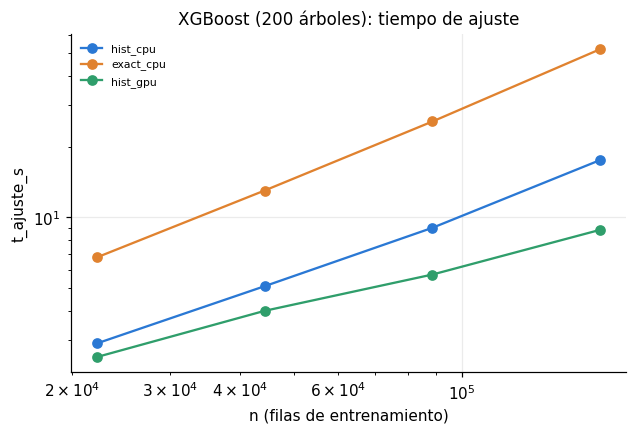

,estrategia,n,t_ajuste_s,t_inferencia_s,arboles,auc
0,hist_cpu,22140,2.9067,0.0832,200,0.7295
1,exact_cpu,22140,6.7540,0.0777,200,0.7272
2,hist_gpu,22140,2.5437,0.3768,200,0.7272
3,hist_cpu,44281,5.0959,0.0843,200,0.7413
4,exact_cpu,44281,13.0168,0.0821,200,0.7459
5,hist_gpu,44281,4.0024,0.4398,200,0.7447
6,hist_cpu,88562,9.0356,0.0816,200,0.7555
7,exact_cpu,88562,25.6140,0.0752,200,0.7560
8,hist_gpu,88562,5.7146,0.3511,200,0.7539
9,hist_cpu,177125,17.5640,0.0833,200,0.7632


,estrategia,exponente,intercepto,r2
0,hist_cpu,0.861,-7.571,0.998
1,exact_cpu,0.982,-7.925,1.000
2,hist_gpu,0.592,-4.972,0.998


Aceleración GPU frente a CPU (hist, n completo): 2.0x
Aceleración hist frente a exact (CPU, n completo): 3.0x


In [9]:
import xgboost as xgb
PARAMS_XGB = dict(learning_rate=0.1, max_depth=6, min_child_weight=5, subsample=0.8,
                  colsample_bytree=0.5, reg_lambda=1.0, random_state=config.SEMILLA,
                  n_jobs=config.NUCLEOS, eval_metric="auc")
N_ARBOLES = 50 if config.MODO_PRUEBA else 200

def experimento_xgb():
    filas = []
    Xa, ya, Xe, ye = mod.separar_parada_temprana(X_tr, y_tr, "clasificacion")
    def correr(nombre, n, **kw):
        m = xgb.XGBClassifier(**{**PARAMS_XGB, **kw})
        t0 = time.perf_counter()
        if kw.get("early_stopping_rounds"):
            m.fit(Xa[:n], ya[:n], eval_set=[(Xe, ye)], verbose=False)
        else:
            m.fit(Xa[:n], ya[:n], verbose=False)
        t_fit = time.perf_counter() - t0
        t0 = time.perf_counter()
        s = m.predict_proba(X_va)[:, 1]
        t_inf = time.perf_counter() - t0
        filas.append({"estrategia": nombre, "n": n, "t_ajuste_s": t_fit, "t_inferencia_s": t_inf,
                      "arboles": int(m.get_booster().num_boosted_rounds()),
                      "auc": roc_auc_score(y_va, s)})
        print(f"  {nombre:28s} n={n:>7,} {t_fit:8.1f} s  AUC {filas[-1]['auc']:.4f}", flush=True)
    for frac in FRACCIONES:
        n = int(frac * len(ya))
        correr("hist_cpu", n, n_estimators=N_ARBOLES, tree_method="hist", device="cpu")
        correr("exact_cpu", n, n_estimators=N_ARBOLES, tree_method="exact")
        if config.DISPOSITIVO_XGB == "cuda":
            correr("hist_gpu", n, n_estimators=N_ARBOLES, tree_method="hist", device="cuda")
    n = len(ya)
    correr("hist_cpu_sin_parada_2000", n, n_estimators=2000 if not config.MODO_PRUEBA else 200,
           tree_method="hist", learning_rate=0.05, device=config.DISPOSITIVO_XGB)
    correr("hist_cpu_con_parada", n, n_estimators=2000 if not config.MODO_PRUEBA else 200,
           tree_method="hist", learning_rate=0.05, early_stopping_rounds=50,
           device=config.DISPOSITIVO_XGB)
    return pd.DataFrame(filas)

xgb_res = cx.experimento_en_disco(DIR_CX / "xgboost.csv", experimento_xgb)
if xgb_res is not None:
    base = xgb_res[xgb_res["estrategia"].isin(["hist_cpu", "exact_cpu", "hist_gpu"])]
    exp_xgb = graficar_escalamiento(base, "estrategia", "t_ajuste_s",
                                    f"XGBoost ({N_ARBOLES} árboles): tiempo de ajuste",
                                    "05_xgb_escalamiento")
    plt.show()
    display(xgb_res.style.format(precision=4))
    display(exp_xgb.style.format(precision=3))
    g = xgb_res[xgb_res["n"] == xgb_res["n"].max()].set_index("estrategia")["t_ajuste_s"]
    if "hist_gpu" in g:
        print(f"Aceleración GPU frente a CPU (hist, n completo): {g['hist_cpu'] / g['hist_gpu']:.1f}x")
    print(f"Aceleración hist frente a exact (CPU, n completo): {g['exact_cpu'] / g['hist_cpu']:.1f}x")

## 7. SVM: núcleo completo frente a aproximaciones lineales

`SVC` con núcleo RBF resuelve un problema dual cuadrático sobre la matriz de núcleo n x n: entre
O(n²) y O(n³) en tiempo y O(n²) en memoria. Con ~200 mil filas es inviable (la matriz de núcleo
completa ocuparía ~150 GB en float32), de modo que **se mide su escalamiento en tamaños crecientes
hasta 16 mil filas** y se extrapola con el exponente estimado; es el experimento de "variar n de forma
controlada" que sugiere la guía. Frente a él: `LinearSVC` (O(i·n·p)), `SGDClassifier` con pérdida
bisagra y Nystroem (500 componentes) + `LinearSVC`, medidos también sobre el conjunto completo.

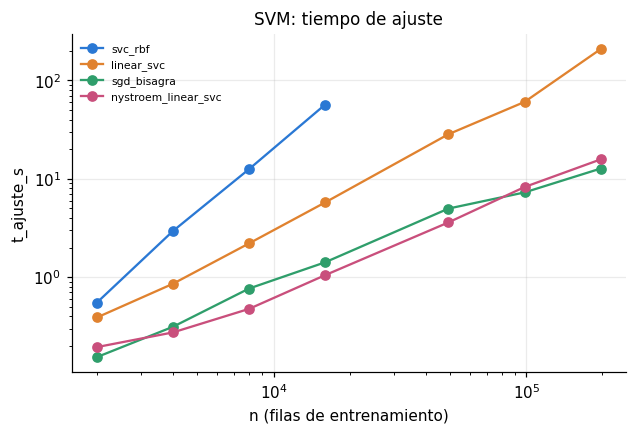

,estrategia,exponente,intercepto,r2
0,svc_rbf,2.216,-17.386,0.999
1,linear_svc,1.362,-11.400,0.998
2,sgd_bisagra,0.974,-9.151,0.992
3,nystroem_linear_svc,1.005,-9.559,0.991


SVC RBF extrapolado a n = 196,806: 4.1 horas por ajuste (exponente 2.22)


In [10]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline

N_SVC = [100, 200, 400, 800] if config.MODO_PRUEBA else [2000, 4000, 8000, 16000]
GAMMA = 1.0 / p

def experimento_svm():
    filas = []
    def correr(nombre, f, Xs, ys):
        t0 = time.perf_counter(); m = f().fit(Xs, ys); t_fit = time.perf_counter() - t0
        t0 = time.perf_counter(); s = m.decision_function(X_va[:5000]); t_inf = time.perf_counter() - t0
        filas.append({"estrategia": nombre, "n": len(ys), "t_ajuste_s": t_fit,
                      "t_inferencia_5000_s": t_inf, "auc": roc_auc_score(y_va[:5000], s)})
        print(f"  {nombre:22s} n={len(ys):>7,} {t_fit:8.1f} s", flush=True)
    for n in N_SVC:
        Xs, ys = X_tr[orden[:n]], y_tr[orden[:n]]
        correr("svc_rbf", lambda: SVC(kernel="rbf", gamma=GAMMA, C=1.0, cache_size=2000), Xs, ys)
        correr("linear_svc", lambda: LinearSVC(C=0.01, dual="auto", max_iter=5000), Xs, ys)
        correr("sgd_bisagra", lambda: SGDClassifier(loss="hinge", alpha=1e-4,
                                                    random_state=config.SEMILLA), Xs, ys)
        correr("nystroem_linear_svc", lambda: make_pipeline(
            Nystroem(gamma=GAMMA, n_components=min(500, n), random_state=config.SEMILLA),
            LinearSVC(C=0.01, dual="auto", max_iter=5000)), Xs, ys)
    for frac in FRACCIONES[1:]:
        Xs, ys = sub(frac)
        correr("linear_svc", lambda: LinearSVC(C=0.01, dual="auto", max_iter=5000), Xs, ys)
        correr("sgd_bisagra", lambda: SGDClassifier(loss="hinge", alpha=1e-4,
                                                    random_state=config.SEMILLA), Xs, ys)
        correr("nystroem_linear_svc", lambda: make_pipeline(
            Nystroem(gamma=GAMMA, n_components=config.NYSTROEM_COMPONENTES, random_state=config.SEMILLA),
            LinearSVC(C=0.01, dual="auto", max_iter=5000)), Xs, ys)
    return pd.DataFrame(filas)

svm_res = cx.experimento_en_disco(DIR_CX / "svm.csv", experimento_svm)
if svm_res is not None:
    exp_svm = graficar_escalamiento(svm_res, "estrategia", "t_ajuste_s",
                                    "SVM: tiempo de ajuste", "05_svm_escalamiento")
    plt.show()
    display(exp_svm.style.format(precision=3))
    e = exp_svm.set_index("estrategia")
    if "svc_rbf" in e.index:
        g = svm_res[svm_res["estrategia"] == "svc_rbf"].sort_values("n").iloc[-1]
        t_ext = g["t_ajuste_s"] * (n_total / g["n"]) ** e.loc["svc_rbf", "exponente"]
        print(f"SVC RBF extrapolado a n = {n_total:,}: {t_ext / 3600:,.1f} horas por ajuste "
              f"(exponente {e.loc['svc_rbf', 'exponente']:.2f})")

## 8. Random Forest: scikit-learn en CPU frente al bosque de XGBoost en GPU

La estimación de tiempos del capítulo 02 mostró que el `RandomForestClassifier` de scikit-learn se
llevaba el 72 % del tiempo de todo el estudio (~115 de 160 horas). Por eso el estudio usa el modo
bosque aleatorio de XGBoost (`XGBRFClassifier`): los mismos árboles independientes con submuestreo de
filas y de columnas por nodo, pero con cortes buscados sobre histogramas de 256 bins y construidos en
la GPU. Se comparan las tres variantes con la configuración central del espacio sobre el conjunto
completo de la partición `e0`.

In [11]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
def experimento_bosques():
    p_ = espacios.espacio("clasificacion", "random_forest").centro()
    h0 = y_tr.mean() * (1 - y_tr.mean())
    variantes = {
        "sklearn_cpu": lambda: RandomForestClassifier(
            n_estimators=int(p_["n_estimators"]), max_depth=int(p_["max_depth"]),
            min_samples_leaf=int(p_["min_samples_leaf"]), max_features=float(p_["max_features"]),
            max_samples=float(p_["max_samples"]), n_jobs=config.NUCLEOS, random_state=config.SEMILLA),
        "xgbrf_cpu": lambda: xgb.XGBRFClassifier(
            n_estimators=int(p_["n_estimators"]), max_depth=int(p_["max_depth"]),
            min_child_weight=float(p_["min_samples_leaf"]) * h0, colsample_bynode=float(p_["max_features"]),
            subsample=float(p_["max_samples"]), tree_method="hist", device="cpu",
            n_jobs=config.NUCLEOS, random_state=config.SEMILLA),
    }
    if config.DISPOSITIVO_XGB == "cuda":
        variantes["xgbrf_gpu"] = lambda: xgb.XGBRFClassifier(
            n_estimators=int(p_["n_estimators"]), max_depth=int(p_["max_depth"]),
            min_child_weight=float(p_["min_samples_leaf"]) * h0, colsample_bynode=float(p_["max_features"]),
            subsample=float(p_["max_samples"]), tree_method="hist", device="cuda",
            random_state=config.SEMILLA)
    filas = []
    for nombre, f in variantes.items():
        t0 = time.perf_counter(); m = f().fit(X_tr, y_tr); t_fit = time.perf_counter() - t0
        t0 = time.perf_counter(); s = m.predict_proba(X_va)[:, 1]; t_inf = time.perf_counter() - t0
        mem, _ = cx.medir_memoria_rss(lambda: f().fit(X_tr[:20000], y_tr[:20000]))
        filas.append({"estrategia": nombre, "n": len(y_tr), "t_ajuste_s": t_fit, "t_inferencia_s": t_inf,
                      "auc": roc_auc_score(y_va, s), "pico_memoria_20k_mb": mem})
        print(f"  {nombre:12s} {t_fit:7.1f} s  AUC {filas[-1]['auc']:.4f}", flush=True)
    df = pd.DataFrame(filas)
    df["aceleracion"] = df["t_ajuste_s"].iloc[0] / df["t_ajuste_s"]
    return df

bosques = cx.experimento_en_disco(DIR_CX / "random_forest_motores.csv", experimento_bosques)
if bosques is not None:
    display(bosques.style.format(precision=4))

,estrategia,n,t_ajuste_s,t_inferencia_s,auc,pico_memoria_20k_mb,aceleracion
0,sklearn_cpu,196806,67.8464,0.2930,0.7386,39.8164,1.0000
1,xgbrf_cpu,196806,40.7472,0.1383,0.7383,140.8047,1.6651
2,xgbrf_gpu,196806,30.9255,0.5311,0.7379,62.1133,2.1939


**Lectura.** Con la configuración central del espacio y la partición `e0` completa, el bosque de
XGBoost en la GPU ajusta en 30.9 s frente a 67.8 s del `RandomForestClassifier` de scikit-learn con
11 hilos (2.2 veces más rápido) y 40.7 s del mismo XGBRF en la CPU (1.7 veces). La inferencia en la
GPU es más lenta (0.53 s frente a 0.29 s) por la copia de los datos de ida y vuelta. El AUC
prácticamente no cambia (0.7386 → 0.7379, −0.0006): buscar los cortes sobre histogramas de 256 bins y
muestrear sin reemplazo, en lugar de cortes exactos y bootstrap, no altera la capacidad de ordenar.
La ganancia de la GPU es útil pero no espectacular; su precio apareció en otra parte, en sus 6 GB de
memoria, que algunas configuraciones del espacio de búsqueda con SMOTE y ADASYN excedieron (anexo A).

## 9. Paralelización

### 9.1 `n_jobs` en Random Forest (scikit-learn)

Los árboles de un bosque son independientes: el ajuste es "vergonzosamente paralelo" y la aceleración
ideal es lineal en el número de hilos. La parte no paralelizable (preparar los datos, agregar) la
limita según la ley de Amdahl.

In [12]:
from sklearn.ensemble import RandomForestClassifier
def experimento_rf():
    hilos = sorted({1, 2, 4, config.NUCLEOS})
    filas = []
    for h in hilos:
        f = lambda: RandomForestClassifier(n_estimators=20 if config.MODO_PRUEBA else 100,
                                           max_depth=12, max_features=0.1, min_samples_leaf=50,
                                           n_jobs=h, random_state=config.SEMILLA).fit(X_tr, y_tr)
        r = cx.medir(f, repeticiones=1)
        filas.append({"hilos": h, "t_ajuste_s": r["media"]})
        print(f"  n_jobs={h}: {r['media']:.1f} s", flush=True)
    df = pd.DataFrame(filas)
    df["aceleracion"] = df["t_ajuste_s"].iloc[0] / df["t_ajuste_s"]
    df["eficiencia"] = df["aceleracion"] / df["hilos"]
    return df

rf_par = cx.experimento_en_disco(DIR_CX / "rf_paralelo.csv", experimento_rf)
if rf_par is not None:
    display(rf_par.style.format(precision=2))

,hilos,t_ajuste_s,aceleracion,eficiencia
0,1,323.97,1.00,1.00
1,2,135.18,2.40,1.20
2,4,79.68,4.07,1.02
3,11,40.20,8.06,0.73


### 9.2 Backends de joblib para los pliegues internos

En el estudio, los pliegues internos de los modelos de un solo hilo (logística, Naive Bayes, árbol,
SVM, Ridge, Lasso) se ajustan en paralelo con joblib. Se compara ejecutar los 3 pliegues internos de
una logística en serie, con el backend `threading` (hilos: comparten memoria pero compiten por el
GIL en el código Python) y con `loky` (procesos: sin GIL; las matrices se pasan mapeadas en memoria
para no copiarlas).

In [13]:
from joblib import Parallel, delayed
def experimento_backends():
    params = {"C": 0.01, "penalizacion": "l2"}
    args = []
    for pi in internas:
        Xt, yt, Xb, es = cache.entrenamiento(pi, "clasificacion", "logistica", "ninguno")
        args.append(("clasificacion", "logistica", params, "ninguno", Xt, yt, pi.X_va, pi.y_va,
                     config.SEMILLA, "cpu", Xb, es, 1))
    filas = []
    t0 = time.perf_counter(); [ex._evaluar_interna(*a) for a in args]
    filas.append({"backend": "serie", "t_s": time.perf_counter() - t0})
    for backend in ("threading", "loky"):
        t0 = time.perf_counter()
        Parallel(n_jobs=len(args), backend=backend)(delayed(ex._evaluar_interna)(*a) for a in args)
        filas.append({"backend": backend, "t_s": time.perf_counter() - t0})
    df = pd.DataFrame(filas)
    df["aceleracion"] = df["t_s"].iloc[0] / df["t_s"]
    return df

backends = cx.experimento_en_disco(DIR_CX / "joblib_backends.csv", experimento_backends)
if backends is not None:
    display(backends.style.format(precision=2))

,backend,t_s,aceleracion
0,serie,12.21,1.00
1,threading,5.56,2.20
2,loky,21.90,0.56


### 9.3 Cómputo distribuido (Dask, Ray)

Con 700 unidades independientes, el estudio es paralelizable al nivel de unidad, y Dask o Ray
permitirían repartirlas entre varias máquinas. En este proyecto no se justifican: se dispone de un
solo equipo de 16 GB de RAM, y el paralelismo que ya existe (hilos en Random Forest, XGBoost y FAISS;
GPU en XGBoost; procesos para los pliegues internos de los modelos de un hilo) satura sus núcleos.
Ejecutar varias unidades a la vez multiplicaría el uso de memoria (cada una mantiene su partición
balanceada y su modelo) sin aumentar el cómputo disponible. El diseño por unidades atómicas guardadas
en disco es, sin embargo, exactamente el que permitiría distribuir el estudio sin cambios: cada
trabajador ejecutaría `ejecutar_unidad` sobre una lista de claves.

## 10. Tabla resumen: estándar frente a optimizado

In [14]:
def fila(modelo, est_std, est_opt, df, col_t, col_inf=None, col_mem=None, filtro_n=True):
    if df is None:
        return None
    d = df[df["n"] == df["n"].max()] if (filtro_n and "n" in df) else df
    d = d.set_index("estrategia")
    if est_std not in d.index or est_opt not in d.index:
        return None
    r = {"Modelo": modelo, "Estándar": est_std, "Optimizado": est_opt,
         "t_entrenamiento_std_s": d.loc[est_std, col_t], "t_entrenamiento_opt_s": d.loc[est_opt, col_t]}
    if col_inf:
        r["t_inferencia_std_s"] = d.loc[est_std, col_inf]; r["t_inferencia_opt_s"] = d.loc[est_opt, col_inf]
    if col_mem:
        r["memoria_std_mb"] = d.loc[est_std, col_mem]; r["memoria_opt_mb"] = d.loc[est_opt, col_mem]
    if "auc" in d:
        r["AUC_std"] = d.loc[est_std, "auc"]; r["AUC_opt"] = d.loc[est_opt, "auc"]
        r["ΔAUC"] = r["AUC_opt"] - r["AUC_std"]
    return r

filas = [
    fila("KNN", "sklearn_bruta_p_original", "faiss_plano_pca", knn, "t_construccion_s", "t_consultas_s"),
    fila("KNN (aprox.)", "faiss_plano_pca", "faiss_ivf_pca", knn, "t_construccion_s", "t_consultas_s"),
    fila("KNN (GPU)", "faiss_plano_pca", "torch_gpu_pca", knn, "t_construccion_s", "t_consultas_s"),
    fila("Random Forest", "sklearn_cpu", "xgbrf_gpu" if config.DISPOSITIVO_XGB == "cuda" else "xgbrf_cpu",
         bosques, "t_ajuste_s", "t_inferencia_s", col_mem="pico_memoria_20k_mb"),
    fila("Ridge", "ridge_cholesky", "ridge_saga", lineales, "t_ajuste_s"),
    fila("Lasso", "lasso_cd_sin_gram", "lasso_cd_gram", lineales, "t_ajuste_s"),
    fila("Logística", "logistica_lbfgs", "logistica_saga", lineales, "t_ajuste_s"),
    fila("Naive Bayes", "fit_completo", "partial_fit_lotes", nb_res, "t_ajuste_s",
         col_mem="pico_memoria_mb", filtro_n=False),
    fila("XGBoost", "exact_cpu", "hist_cpu", xgb_res, "t_ajuste_s", "t_inferencia_s"),
    fila("XGBoost (GPU)", "hist_cpu", "hist_gpu", xgb_res, "t_ajuste_s", "t_inferencia_s"),
    fila("XGBoost (parada)", "hist_cpu_sin_parada_2000", "hist_cpu_con_parada", xgb_res,
         "t_ajuste_s", "t_inferencia_s"),
]
if svm_res is not None:
    d = svm_res
    n_max_svc = d[d["estrategia"] == "svc_rbf"]["n"].max()
    filas.append(fila("SVM (n = %d)" % n_max_svc, "svc_rbf", "nystroem_linear_svc",
                      d[d["n"] == n_max_svc].assign(n=0), "t_ajuste_s", "t_inferencia_5000_s"))
resumen_cx = pd.DataFrame([f for f in filas if f])
teo = {"KNN": ("O(n p) por consulta", "O(n d) por consulta (d = 40)"),
       "KNN (aprox.)": ("O(n d)", "O((n / nlist) d nprobe)"),
       "KNN (GPU)": ("O(n d) por consulta, CPU", "O(n d) por consulta, miles de consultas en paralelo"),
       "Random Forest": ("O(T m n log² n), cortes exactos", "O(T m n), histogramas de B bins, GPU"),
       "Ridge": ("O(n p² + p³)", "O(n p) por época"), "Lasso": ("O(n p) por iteración", "O(n p²) + O(p²) por iteración"),
       "Logística": ("O(i n p)", "O(n p) por época"),
       "Naive Bayes": ("memoria O(n p)", "memoria O(lote · p)"),
       "XGBoost": ("O(T K p n log n)", "O(T K p n), B = 256"), "XGBoost (GPU)": ("CPU", "GPU"),
       "XGBoost (parada)": ("T = 2000", "T* elegido por validación")}
resumen_cx["Complejidad estándar"] = resumen_cx["Modelo"].map(lambda m: teo.get(m, ("O(n² p) a O(n³)",))[0])
resumen_cx["Complejidad optimizada"] = resumen_cx["Modelo"].map(
    lambda m: teo.get(m, ("", "O(n m p + m³) + O(i n m)"))[1])
# Memoria: pico de memoria residente del proceso, medido donde la optimizacion la afecta.
resumen_cx["memoria medida en"] = resumen_cx["Modelo"].map(
    {"Naive Bayes": "ajuste completo (196,806 filas)",
     "Random Forest": "ajuste con 20,000 filas; RAM del proceso, sin la memoria de la GPU"}).fillna("-")
display(resumen_cx.style.format(precision=4, na_rep="-"))
resumen_cx.to_csv(DIR_CX / "resumen_estandar_vs_optimizado.csv", index=False)
cache.liberar()

,Modelo,Estándar,Optimizado,t_entrenamiento_std_s,t_entrenamiento_opt_s,t_inferencia_std_s,t_inferencia_opt_s,AUC_std,AUC_opt,ΔAUC,memoria_std_mb,memoria_opt_mb,Complejidad estándar,Complejidad optimizada,memoria medida en
0,KNN,sklearn_bruta_p_original,faiss_plano_pca,0.0954,0.0119,7.6334,0.5846,0.6069,0.6547,0.0478,-,-,O(n p) por consulta,O(n d) por consulta (d = 40),-
1,KNN (aprox.),faiss_plano_pca,faiss_ivf_pca,0.0119,1.0697,0.5846,0.0578,0.6547,0.6484,-0.0063,-,-,O(n d),O((n / nlist) d nprobe),-
2,KNN (GPU),faiss_plano_pca,torch_gpu_pca,0.0119,1.1984,0.5846,0.4319,0.6547,0.6547,0.0000,-,-,"O(n d) por consulta, CPU","O(n d) por consulta, miles de consultas en paralelo",-
3,Random Forest,sklearn_cpu,xgbrf_gpu,67.8464,30.9255,0.2930,0.5311,0.7386,0.7379,-0.0006,39.8164,62.1133,"O(T m n log² n), cortes exactos","O(T m n), histogramas de B bins, GPU","ajuste con 20,000 filas; RAM del proceso, sin la memoria de la GPU"
4,Ridge,ridge_cholesky,ridge_saga,0.5913,89.0892,-,-,0.7515,0.7521,0.0007,-,-,O(n p² + p³),O(n p) por época,-
5,Lasso,lasso_cd_sin_gram,lasso_cd_gram,45.7329,1.2337,-,-,0.7522,0.7522,-0.0000,-,-,O(n p) por iteración,O(n p²) + O(p²) por iteración,-
6,Logística,logistica_lbfgs,logistica_saga,4.2655,162.1189,-,-,0.7542,0.7541,-0.0001,-,-,O(i n p),O(n p) por época,-
7,Naive Bayes,fit_completo,partial_fit_lotes,0.8721,0.9020,-,-,0.6440,0.6441,0.0002,1329.7852,561.0117,memoria O(n p),memoria O(lote · p),"ajuste completo (196,806 filas)"
8,XGBoost,exact_cpu,hist_cpu,52.0784,17.5640,0.0820,0.0833,0.7628,0.7632,0.0003,-,-,O(T K p n log n),"O(T K p n), B = 256",-
9,XGBoost (GPU),hist_cpu,hist_gpu,17.5640,8.8615,0.0833,0.3933,0.7632,0.7622,-0.0010,-,-,CPU,GPU,-


**Lectura.** La tabla responde a la Sección 4.4 de la guía. Cuatro optimizaciones fueron decisivas
para que el estudio fuera viable:

1. **Parada temprana en XGBoost**: 3.8 veces más rápida y además +0.011 de AUC (413 árboles frente a
   2,000, que sobreajustan).
2. **`hist` frente a `exact`**: 3.0 veces más rápido sin pérdida de AUC (+0.0003), con exponentes 0.86
   y 0.98; lo que se ahorra es el log n de ordenar cada columna.
3. **Nystroem + modelo lineal frente a SVC con núcleo RBF**: 54 veces más rápido con 16,000 filas y
   mejor AUC (0.696 frente a 0.663). El SVC exacto crece con exponente 2.2 y, extrapolado a las
   196,806 filas, tardaría ~4.1 h por ajuste: inviable para 20 evaluaciones en 15 particiones internas.
4. **PCA + búsqueda vectorizada en KNN**: 7 a 13 veces más rápida por consulta y +0.048 de AUC.

Otras dos son ahorros sin efecto en el AUC: la matriz de Gram en Lasso (37 veces) y `partial_fit` en
Naive Bayes, que no acelera pero reduce el pico de memoria de 1,330 a 561 MB (−58 %) con parámetros
que coinciden salvo diferencias numéricas en la cuarta cifra decimal. En memoria, el bosque de
XGBoost en la GPU ocupa 62 MB de RAM al ajustar 20,000 filas frente a 40 MB de scikit-learn (la
versión de XGBoost en la CPU, 141 MB, por las matrices de cuantiles); la memoria de la GPU no se
cuenta ahí y fue, en cambio, la que limitó el estudio. La GPU aporta 2.0 veces en
XGBoost y 2.2 en Random Forest: útil, pero menos que los cambios de algoritmo. En dos casos la
optimización que sugiere la guía no lo es en este problema: SAGA es 150 y 38 veces más lento que
Cholesky y lbfgs con datos densos y p moderado.

En paralelismo, Random Forest escala bien hasta 4 hilos (aceleración 4.1) y llega a 8.1 con 11
(eficiencia 0.73, compatible con una fracción serial de ~4 % según Amdahl; la eficiencia superior a 1
con 2 hilos indica que la medición de un hilo, la primera, incluyó costes de calentamiento). Para los
pliegues internos, los hilos aceleran 2.2 veces, mientras que `loky` resulta más lento que la serie
(0.56): la medición es una sola llamada e incluye el arranque de los procesos, un coste que en el
estudio se amortiza porque el ejecutor se reutiliza durante las 20 evaluaciones. Aun así, para
modelos cuyo trabajo pesado libera el GIL, como la logística con lbfgs, los hilos son la opción más
barata, y `loky` fue además fuente de fallos durante el estudio (anexo A): es la primera mejora
pendiente de la infraestructura.